# Bit-Flipping Experiment

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jeertmans/HER-with-JAX/blob/main/bit_flipping.ipynb) [![arXiv](https://img.shields.io/badge/arXiv-1707.01495-b31b1b.svg)](https://arxiv.org/abs/1707.01495)

This is a minimalist JAX implementation of the bit-flipping experiment described in the *Hindsight Experience Replay* (HER) paper.

Any bug, question, or mismatch with the original implementation, should be reported to: https://github.com/jeertmans/HER-with-JAX/issues.

## Task

An agent is given a target bit sequence of length `num_bits`, referred to as `goal` in the code, and a random initial bit sequence of the same length, referred to as `state` in the code. At each timestep, the agent uses a neural network (`Network`) to decide which bit of the state to flip. Here, the input of the network is simply a vector containing the current `state` and the target `goal`, concatenated into a vector of size `2 * num_bits`.

The goal is for the agent to learn how to reach the target state in a maximum of `num_timesteps`.

For large `num_bits`, the total number of possible states is exponentially large, making it statistically impossible to reach the desired state in a limited number of steps. This is where HER becomes useful.

## Major differences with the official implementation

The official implementation is available [here](https://github.com/hemilpanchiwala/Hindsight-Experience-Replay)  and is implemented using PyTorch.

Unlike PyTorch, JAX enforces stricter rules to ensure code compatibility with backward automatic differentiation and just-in-time compilation. This mainly results in a functional programming style where all objects are immutable. Consequently, methods never update an object in place, but rather return a new copy of that object.

Additionally, JAX is not a machine learning library. This is why we use Equinox to create the neural network and perform all PyTree manipulations and Optax for the learning part.

Finally, to take full advantage of just-in-time compilation, some methods were rewritten so that they do not depend on static values (see, for example, how we moved the actual learning step, `_learn`, outside of `learn`). Otherwise, JAX would have to recompile the code of the optimization step multiple times.

## (Optional) Install dependencies on Colab

In [1]:
# Installs project dependencies, required on Google Colab. For a local installation
# read the guidelines from https://github.com/jeertmans/HER-with-JAX?tab=readme-ov-file#installing

try:
    import google.colab

    !pip install git+https://github.com/jeertmans/HER-with-JAX.git
except ImportError:
    pass

## Imports and setup

In [2]:
from typing import Self

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import treescope
from jaxtyping import Array, Bool, Float, Int, PRNGKeyArray
from tqdm.notebook import tqdm

In [3]:
treescope.basic_interactive_setup()  # Setup pretty-printing

In [4]:
jax.devices()

[CudaDevice(id=0)]

## Environment

In [5]:
class Environment(eqx.Module):
    state: Float[Array, " num_bits"]
    goal: Float[Array, " num_bits"]
    done: Bool[Array, " "]
    reward: Float[Array, " "]

    def __init__(self, num_bits: int, *, key: PRNGKeyArray) -> None:
        key = jax.random.key(1234)
        key_state, key_goal = jax.random.split(key)

        # We prefer to init as float, as we would otherwise need implicit casting from int to float
        self.state = jax.random.randint(key_state, (num_bits,), 0, 2).astype(float)
        self.goal = jax.random.randint(key_goal, (num_bits,), 0, 2).astype(float)
        self.done = jnp.array(False)
        self.reward = jnp.array(-1.0)

    @jax.jit
    def take_step(self, action: Int[Array, " "]) -> Self:
        assert action.shape == ()
        assert action.dtype == jnp.int32
        state = self.state.at[action].apply(lambda x: 1.0 - x)
        done = (state == self.goal).all()
        reward = jax.lax.cond(done, lambda: 0.0, lambda: -1.0)
        return eqx.tree_at(
            lambda env: (env.state, env.done, env.reward), self, (state, done, reward)
        )

## Deep Q-Network

In [6]:
class Network(eqx.Module):
    layers: list[eqx.nn.Linear]

    def __init__(self, input_size: int, output_size: int, *, key: PRNGKeyArray) -> None:
        keys = jax.random.split(key, 3)
        self.layers = [
            eqx.nn.Linear(input_size, 512, key=keys[0]),
            eqx.nn.Linear(512, 256, key=keys[1]),
            eqx.nn.Linear(256, output_size, key=keys[2]),
        ]

    def __call__(self, x: Float[Array, " input_size"]) -> Float[Array, " output_size"]:
        for layer in self.layers[:-1]:
            x = layer(x)
            x = jax.nn.relu(x)

        return self.layers[-1](x)

## HER memory

In [7]:
class Memory(eqx.Module):
    memory_size: int = eqx.field(static=True)

    states: Float[Array, "memory_size input_size"]
    actions: Int[Array, " memory_size"]
    rewards: Float[Array, " memory_size"]
    next_states: Float[Array, "memory_size input_size"]
    dones: Bool[Array, " memory_size"]
    goals: Float[Array, "memory_size input_size"]
    counter: Int[Array, " "]

    def __init__(self, memory_size: int, input_size: int):
        self.memory_size = memory_size

        self.states = jnp.empty((memory_size, input_size))
        self.actions = jnp.empty((memory_size,), dtype=int)
        self.rewards = jnp.empty((memory_size,))
        self.next_states = jnp.empty((memory_size, input_size))
        self.dones = jnp.empty((memory_size,), dtype=bool)
        self.goals = jnp.empty((memory_size, input_size))

        self.counter = jnp.array(0)

    def add_experience(
        self,
        state: Float[Array, " input_size"],
        action: Int[Array, " "],
        reward: Float[Array, " "],
        next_state: Float[Array, " input_size"],
        done: Bool[Array, " "],
        goal: Float[Array, " input_size"],
    ) -> Self:
        index = self.counter % self.memory_size
        return eqx.tree_at(
            lambda mem: (
                mem.states,
                mem.actions,
                mem.rewards,
                mem.next_states,
                mem.dones,
                mem.goals,
                mem.counter,
            ),
            self,
            (
                self.states.at[index].set(state),
                self.actions.at[index].set(action),
                self.rewards.at[index].set(reward),
                self.next_states.at[index].set(next_state),
                self.dones.at[index].set(done),
                self.goals.at[index].set(goal),
                self.counter + 1,
            ),
        )

    def sample_experience(
        self, batch_size: int, *, key: PRNGKeyArray
    ) -> tuple[
        Float[Array, "batch_size input_size"],
        Int[Array, " batch_size"],
        Float[Array, " batch_size"],
        Float[Array, "batch_size input_size"],
        Bool[Array, " batch_size"],
        Float[Array, "batch_size input_size"],
    ]:
        # JIT-friendly way of sampling indices up to min(counter, memory_size)
        indices = jnp.arange(self.memory_size)
        p = jnp.where(indices >= self.counter, 0.0, 1.0)
        indices = jax.random.choice(key, indices, (batch_size,), replace=False, p=p)
        return (
            self.states[indices],
            self.actions[indices],
            self.rewards[indices],
            self.next_states[indices],
            self.dones[indices],
            self.goals[indices],
        )

## Agent

In [8]:
def loss(
    network_eval: Network,
    network_next: Network,
    states: Float[Array, "batch_size input_size"],
    actions: Int[Array, " batch_size"],
    rewards: Float[Array, " batch_size"],
    next_states: Float[Array, "batch_size input_size"],
    dones: Bool[Array, " batch_size"],
    goals: Float[Array, "batch_size input_size"],
    gamma: float,
) -> Float[Array, " "]:
    batch_size = states.shape[0]
    batches = jnp.arange(batch_size)
    preds = jax.vmap(network_eval)(jnp.concat((states, goals), axis=1))[
        batches, actions
    ]
    nexts = jax.vmap(network_next)(jnp.concat((next_states, goals), axis=1)).max(axis=1)
    nexts = jnp.where(dones, 0.0, nexts)
    targets = rewards + gamma * nexts
    return optax.squared_error(targets, preds).mean()  # MSE


class Agent(eqx.Module):
    epsilon: Float[Array, " "]
    steps_count: Int[Array, " "]

    num_actions: int = eqx.field(static=True)
    delta_epsilon: float = eqx.field(static=True)
    min_epsilon: float = eqx.field(static=True)
    batch_size: int = eqx.field(static=True)
    replace_network_every: int = eqx.field(static=True)
    gamma: float = eqx.field(static=True)

    network_eval: Network
    network_next: Network
    memory: Memory

    optim: optax.GradientTransformation
    opt_state: optax.OptState

    def __init__(
        self,
        num_actions: int,
        input_size: int,
        epsilon: float = 0.9,
        delta_epsilon: float = 1e-5,
        min_epsilon: float = 0.1,
        batch_size: int = 64,
        memory_size: int = 10_000,
        replace_network_every: int = 50,
        gamma: float = 0.99,
        optim: optax.GradientTransformation = optax.rmsprop(
            learning_rate=1e-4, decay=0.99
        ),
        *,
        key: PRNGKeyArray,
    ) -> None:
        self.num_actions = num_actions
        self.epsilon = jnp.asarray(epsilon)
        self.delta_epsilon = delta_epsilon
        self.min_epsilon = min_epsilon
        self.batch_size = batch_size
        self.replace_network_every = replace_network_every
        self.gamma = gamma

        key_eval, key_next = jax.random.split(key)
        self.network_eval = Network(
            2 * input_size, output_size=num_actions, key=key_eval
        )
        self.network_next = Network(
            2 * input_size, output_size=num_actions, key=key_next
        )
        self.memory = Memory(memory_size, input_size=input_size)

        self.optim = optim
        self.opt_state = optim.init(eqx.filter(self.network_eval, eqx.is_array))
        self.steps_count = jnp.array(0)

    @eqx.filter_jit
    def choose_action(
        self,
        observation: Float[Array, " input_size"],
        goal: Float[Array, " input_size"],
        *,
        key: PRNGKeyArray,
    ) -> Int[Array, " "]:
        key_greedy, key_action = jax.random.split(key)
        return jax.lax.cond(
            jax.random.uniform(key_greedy) > self.epsilon,
            lambda: self.network_eval(jnp.concat([observation, goal])).argmax(),
            lambda: jax.random.randint(key_action, (), 0, self.num_actions),
        )

    @eqx.filter_jit
    def store_experience(
        self,
        state: Float[Array, " input_size"],
        action: Int[Array, " "],
        reward: Float[Array, " "],
        next_state: Float[Array, " input_size"],
        done: Bool[Array, " "],
        goal: Float[Array, " input_size"],
    ) -> Self:
        return eqx.tree_at(
            lambda agent: agent.memory,
            self,
            self.memory.add_experience(state, action, reward, next_state, done, goal),
        )

    @eqx.filter_jit
    def _learn(self, *, key: PRNGKeyArray) -> Self:
        network_next = jax.lax.cond(
            (self.steps_count % self.replace_network_every) == 0,
            lambda: self.network_eval,
            lambda: self.network_next,
        )

        states, actions, rewards, next_states, dones, goals = (
            self.memory.sample_experience(self.batch_size, key=key)
        )

        grads = eqx.filter_grad(loss)(
            self.network_eval,
            network_next,
            states,
            actions,
            rewards,
            next_states,
            dones,
            goals,
            self.gamma,
        )

        updates, opt_state = self.optim.update(
            grads, self.opt_state, eqx.filter(self.network_eval, eqx.is_array)
        )

        return eqx.tree_at(
            lambda agent: (
                agent.network_eval,
                agent.network_next,
                agent.opt_state,
                agent.steps_count,
                agent.epsilon,
            ),
            self,
            (
                eqx.apply_updates(self.network_eval, updates),
                network_next,
                opt_state,
                self.steps_count + 1,
                (self.epsilon - self.delta_epsilon).clip(min=self.min_epsilon),
            ),
        )

    def learn(self, *, key: PRNGKeyArray) -> Self:
        # We cannot efficiently JIT-compile this comparison
        if self.memory.counter < self.batch_size:
            return self
        return self._learn(key=key)

## Training

In [9]:
num_bits = 8
num_timesteps = num_bits

key = jax.random.key(1234)
key_agent, key_training = jax.random.split(key)

agent = Agent(num_actions=num_bits, input_size=num_bits, key=key_agent)
agent

Agent(
  epsilon=weak_f32[],
  steps_count=weak_i32[],
  num_actions=8,
  delta_epsilon=1e-05,
  min_epsilon=0.1,
  batch_size=64,
  replace_network_every=50,
  gamma=0.99,
  network_eval=Network(
    layers=[
      Linear(
        weight=f32[512,16],
        bias=f32[512],
        in_features=16,
        out_features=512,
        use_bias=True
      ),
      Linear(
        weight=f32[256,512],
        bias=f32[256],
        in_features=512,
        out_features=256,
        use_bias=True
      ),
      Linear(
        weight=f32[8,256],
        bias=f32[8],
        in_features=256,
        out_features=8,
        use_bias=True
      )
    ]
  ),
  network_next=Network(
    layers=[
      Linear(
        weight=f32[512,16],
        bias=f32[512],
        in_features=16,
        out_features=512,
        use_bias=True
      ),
      Linear(
        weight=f32[256,512],
        bias=f32[256],
        in_features=512,
        out_features=256,
        use_bias=True
      ),
      Linear(
        weight=f32[8,256],
        bias=f32[8],
        in_features=256,
        out_features=8,
        use_bias=True
      )
    ]
  ),
  memory=Memory(
    memory_size=10000,
    states=f32[10000,8],
    actions=i32[10000],
    rewards=f32[10000],
    next_states=f32[10000,8],
    dones=bool[10000],
    goals=f32[10000,8],
    counter=weak_i32[]
  ),
  optim=GradientTransformationExtraArgs(
    init=<function chain.<locals>.init_fn>,
    update=<function chain.<locals>.update_fn>
  ),
  opt_state=(
    ScaleByRmsState(
      nu=Network(
        layers=[
          Linear(
            weight=f32[512,16],
            bias=f32[512],
            in_features=16,
            out_features=512,
            use_bias=True
          ),
          Linear(
            weight=f32[256,512],
            bias=f32[256],
            in_features=512,
            out_features=256,
            use_bias=True
          ),
          Linear(
            weight=f32[8,256],
            bias=f32[8],
            in_features=256,
            out_features=8,
            use_bias=True
          )
        ]
      )
    ),
    EmptyState(),
    EmptyState()
  )
)

In [10]:
success_count = 0
num_episodes = 30_000

progress_bar = tqdm(jax.random.split(key_training, num_episodes), leave=False)
print_every = 500

episodes = []
success_rates = []

for episode, key_episode in enumerate(progress_bar):
    key_env, *keys_timesteps = jax.random.split(key_episode, 3)
    env = Environment(num_bits=num_bits, key=key_env)
    state = env.state
    goal = env.goal
    done = False

    transitions = []

    for key_timestep in jax.random.split(keys_timesteps[0], num_timesteps):
        if not done:
            key_action, key_learn = jax.random.split(key_timestep)
            action = agent.choose_action(env.state, env.goal, key=key_action)
            env = env.take_step(action)
            next_state, reward, done = env.state, env.reward, env.done
            agent = agent.store_experience(
                state, action, reward, next_state, done, goal
            )
            transitions.append((state, action, reward, next_state))
            agent = agent.learn(key=key_learn)
            state = next_state
            done = done.item()  # Convert to Python bool

            if done:
                success_count += 1

    if not done:
        new_goal = state

        if not jnp.array_equal(new_goal, goal):
            for p, key_learn in enumerate(
                jax.random.split(keys_timesteps[1], num_timesteps)
            ):
                transition = transitions[p]

                if jnp.array_equal(transition[3], new_goal):
                    agent = agent.store_experience(
                        transition[0],
                        transition[1],
                        jnp.array(0.0),
                        transition[3],
                        jnp.array(True),
                        new_goal,
                    )
                else:
                    agent = agent.store_experience(
                        transition[0],
                        transition[1],
                        transition[2],
                        transition[3],
                        jnp.array(False),
                        new_goal,
                    )
                agent = agent.learn(key=key_learn)

    if episode % print_every == 0:
        success_rate = 100 * success_count / print_every
        progress_bar.set_description(f"Success rate: {success_rate:.2f}%")
        success_count = 0

        episodes.append(episode)
        success_rates.append(success_rate)


agent

  0%|          | 0/30000 [00:00<?, ?it/s]

Agent(
  epsilon=weak_f32[],
  steps_count=weak_i32[],
  num_actions=8,
  delta_epsilon=1e-05,
  min_epsilon=0.1,
  batch_size=64,
  replace_network_every=50,
  gamma=0.99,
  network_eval=Network(
    layers=[
      Linear(
        weight=f32[512,16],
        bias=f32[512],
        in_features=16,
        out_features=512,
        use_bias=True
      ),
      Linear(
        weight=f32[256,512],
        bias=f32[256],
        in_features=512,
        out_features=256,
        use_bias=True
      ),
      Linear(
        weight=f32[8,256],
        bias=f32[8],
        in_features=256,
        out_features=8,
        use_bias=True
      )
    ]
  ),
  network_next=Network(
    layers=[
      Linear(
        weight=f32[512,16],
        bias=f32[512],
        in_features=16,
        out_features=512,
        use_bias=True
      ),
      Linear(
        weight=f32[256,512],
        bias=f32[256],
        in_features=512,
        out_features=256,
        use_bias=True
      ),
      Linear(
        weight=f32[8,256],
        bias=f32[8],
        in_features=256,
        out_features=8,
        use_bias=True
      )
    ]
  ),
  memory=Memory(
    memory_size=10000,
    states=f32[10000,8],
    actions=i32[10000],
    rewards=f32[10000],
    next_states=f32[10000,8],
    dones=bool[10000],
    goals=f32[10000,8],
    counter=weak_i32[]
  ),
  optim=GradientTransformationExtraArgs(
    init=<function chain.<locals>.init_fn>,
    update=<function chain.<locals>.update_fn>
  ),
  opt_state=(
    ScaleByRmsState(
      nu=Network(
        layers=[
          Linear(
            weight=f32[512,16],
            bias=f32[512],
            in_features=16,
            out_features=512,
            use_bias=True
          ),
          Linear(
            weight=f32[256,512],
            bias=f32[256],
            in_features=512,
            out_features=256,
            use_bias=True
          ),
          Linear(
            weight=f32[8,256],
            bias=f32[8],
            in_features=256,
            out_features=8,
            use_bias=True
          )
        ]
      )
    ),
    EmptyState(),
    EmptyState()
  )
)

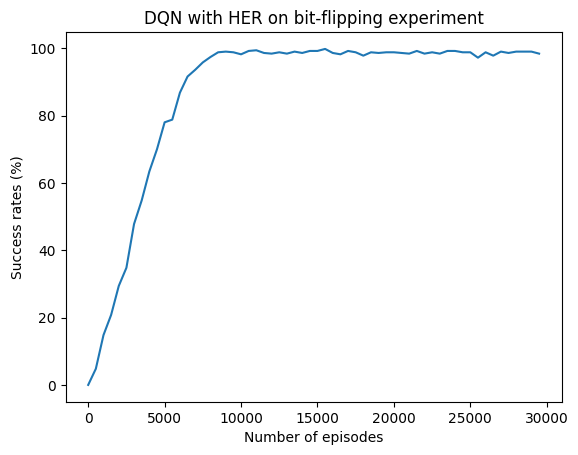

In [11]:
plt.plot(episodes, success_rates)
plt.xlabel("Number of episodes")
plt.ylabel("Success rates (%)")
plt.title("DQN with HER on bit-flipping experiment");

## Comments

As we can see, the above results clearly match [those of the original PyTorch implementation](https://github.com/hemilpanchiwala/Hindsight-Experience-Replay/blob/b79402af027cbd4321e4ae93aeefccdfd1b7d675/results%20and%20plots/dqn_with_her_plots/dqn_plot_with_her.png):

![](https://raw.githubusercontent.com/hemilpanchiwala/Hindsight-Experience-Replay/b79402af027cbd4321e4ae93aeefccdfd1b7d675/results%20and%20plots/dqn_with_her_plots/dqn_plot_with_her.png)

The slight discrepancies between the two curves may be due to (1) different random number generation and (2) the fact that [`optax.rmsprop`](https://optax.readthedocs.io/en/latest/api/optimizers.html#rmsprop) is not strictly equivalent to [`torch.optim.RMSprop`](https://docs.pytorch.org/docs/stable/generated/torch.optim.RMSprop.html).